In [87]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [88]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error,mean_absolute_error,r2_score

In [89]:
from sklearn.preprocessing import PolynomialFeatures

In [90]:
df=pd.read_csv("Ice_cream selling data.csv")

In [91]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [92]:
X=df[["Temperature (°C)"]]
y=df["Ice Cream Sales (units)"]

In [93]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

In [94]:
poly = PolynomialFeatures(degree=2)
updated_xtrain=poly.fit_transform(xtrain)
updated_xtest=poly.transform(xtrain)

In [95]:
model=LinearRegression()
model.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [96]:
y_pred_train=model.predict(updated_xtrain)

In [97]:
y_pred_test=model.predict(updated_xtest)

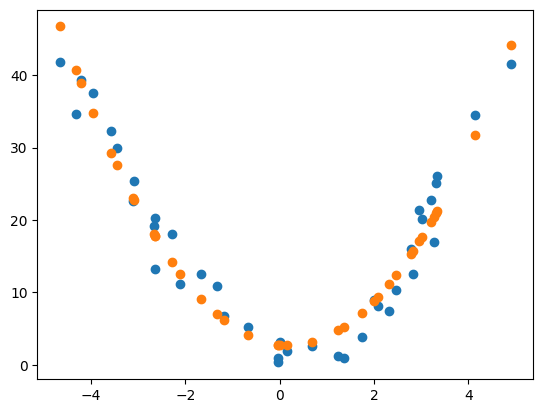

In [98]:
plt.scatter(updated_xtrain[:,1], ytrain)
plt.scatter(updated_xtrain[:,1], y_pred_train)

In [99]:
train_score=r2_score(ytrain,y_pred_train)
train_score

0.9413665676490518

In [100]:
test_score=r2_score(ytest,y_pred_test)
test_score

ValueError: Found input variables with inconsistent numbers of samples: [10, 39]